In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

1. Import Data

In [2]:
listings_data = pd.read_csv('../Data/listings.csv')
reviews_data = pd.read_csv('../Data/reviews.csv')
neighborhoods_data = pd.read_csv('../Data/neighbourhoods.csv')

In [3]:
listings_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 25449 entries, 0 to 25448
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              25449 non-null  int64  
 1   name                            25449 non-null  str    
 2   host_id                         25449 non-null  int64  
 3   host_name                       25447 non-null  str    
 4   neighbourhood_group             25449 non-null  str    
 5   neighbourhood                   25449 non-null  str    
 6   latitude                        25449 non-null  float64
 7   longitude                       25449 non-null  float64
 8   room_type                       25449 non-null  str    
 9   price                           21870 non-null  float64
 10  minimum_nights                  25449 non-null  int64  
 11  number_of_reviews               25449 non-null  int64  
 12  last_review                     22255 non-n

In [4]:
listings_data.shape, reviews_data.shape, neighborhoods_data.shape

((25449, 18), (1763341, 2), (134, 2))

In [5]:
listings_data.set_index("id", inplace=True)

In [6]:
original_listings = listings_data.copy()

2. Data Cleaning

In [7]:
listings_data_numeric = listings_data.select_dtypes(include=np.number)

In [8]:
listings_data.isna().sum()

name                                 0
host_id                              0
host_name                            2
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                             3579
minimum_nights                       0
number_of_reviews                    0
last_review                       3194
reviews_per_month                 3194
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           1159
dtype: int64

In [9]:
listings_data.describe()

,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,2.544900e+04,25449.000000,25449.000000,21870.000000,25449.000000,25449.000000,22255.000000,25449.000000,25449.000000,25449.000000
mean,2.287182e+08,38.762926,-9.207847,248.116049,4.719989,69.289206,1.566873,25.998075,217.148061,13.638257
std,2.214487e+08,0.114548,0.112146,1812.958718,16.810821,110.598085,1.551474,64.004266,129.336846,18.592469
min,1.445500e+04,38.675790,-9.486970,9.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,2.868791e+07,38.711030,-9.287910,75.000000,1.000000,3.000000,0.390000,1.000000,90.000000,0.000000
50%,1.462857e+08,38.719520,-9.147947,110.000000,2.000000,21.000000,1.090000,5.000000,263.000000,5.000000
75%,4.389003e+08,38.746920,-9.135128,167.000000,3.000000,86.000000,2.320000,16.000000,332.000000,21.000000
max,7.196566e+08,39.304030,-8.862100,86733.000000,1000.000000,1787.000000,29.720000,391.000000,365.000000,329.000000


In [10]:
listings_data.describe(include='O')

/tmp/ipykernel_48306/2282621208.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  listings_data.describe(include='O')


,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review,license
count,25449,25447,25449,25449,25449,22255,24290
unique,24514,3804,16,129,4,1661,13613
top,Excelente Quarto Central,Pedro,Lisboa,Santa Maria Maior,Entire home/apt,2025-09-07,Exempt
freq,47,647,17428,3482,18824,760,4882


<Axes: >

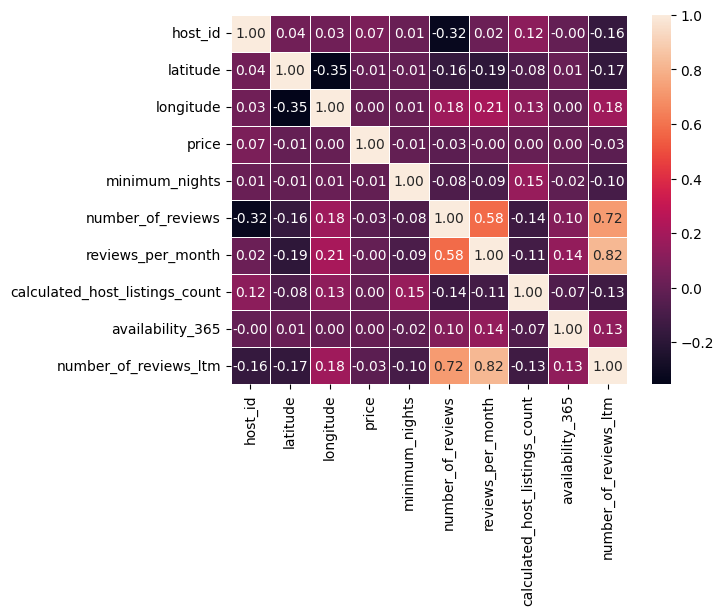

In [11]:
corr_matrix = listings_data_numeric.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidth=0.5)

Weak correlations across key features (especially price) indicate that model-based imputation would introduce noise rather than signal.

Correct **last_review** data type to datetime and **host_id** to string

In [12]:
listings_data["last_review"] = pd.to_datetime(listings_data["last_review"], errors='coerce')
listings_data["host_id"] = listings_data["host_id"].map(str)

In [13]:
listings_data.dtypes

name                                         str
host_id                                      str
host_name                                    str
neighbourhood_group                          str
neighbourhood                                str
latitude                                 float64
longitude                                float64
room_type                                    str
price                                    float64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[us]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
number_of_reviews_ltm                      int64
license                                      str
dtype: object

### Missing Value Strategy

- reviews_per_month:
  Set to 0 only where number_of_reviews == 0

- last_review:
  Left as NaT when no reviews

- price:
  Missing values preserved due to weak correlation and lack of reliable imputation strategy.
  Missing indicator added.

- host_name / license:
  Missing values flagged; no reliable reconstruction available.

Columns with >10% missing were evaluated for imputation strategies.

In [14]:
missing_summary = pd.DataFrame({
    "missing_count": listings_data.isna().sum(),
    "missing_pct": (listings_data.isna().mean() * 100).round(2)
}).sort_values("missing_pct", ascending=False)

missing_summary

,missing_count,missing_pct
price,3579,14.06
last_review,3194,12.55
reviews_per_month,3194,12.55
license,1159,4.55
host_name,2,0.01
name,0,0.00
neighbourhood,0,0.00
neighbourhood_group,0,0.00
host_id,0,0.00
room_type,0,0.00


**host_name** is not critical for downstream analytical tasks and cannot be reliably reconstructed from **host_id**. Therefore, missing values are preserved and flagged.

In [15]:
listings_data[(listings_data['host_name'].isna())]

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
id,,,,,,,,,,,,,,,,,
1119436558815581889,Challet Judith,568673320,NaN,Cascais,Carcavelos e Parede,38.691489,-9.354692,Entire home/apt,266.0,4,26,2025-08-31,1.55,1,17,20,154997/AL
1421801346889033452,Stylish Avenida Apartment,695699847,NaN,Lisboa,Santo Antnio,38.716290,-9.145730,Entire home/apt,162.0,2,3,2025-07-15,0.97,1,4,3,83208/AL


In [16]:
listings_data[(listings_data['host_id'] == 568673320)]

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
id,,,,,,,,,,,,,,,,,


In [17]:
listings_data[(listings_data['host_id'] == 695699847)]

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
id,,,,,,,,,,,,,,,,,


Verify if all columns that have NA in both **last_review** and **reviews_per_month** have 0 reviews. Logically if a house does not have reviews it cannot have a last date for a review and reviews per month would be 0.

In [18]:
listings_data[(listings_data['last_review'].isna()) & (listings_data['reviews_per_month'].isna()) & (listings_data['number_of_reviews'] == 0)]

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
id,,,,,,,,,,,,,,,,,
107159,Noite a bordo barco Yatch Astinor,554343,José,Lisboa,Estrela,38.700650,-9.174910,Private room,360.0,1,0,NaT,NaN,1,365,0,NaN
122572,A confortable room in a nice place,614156,Isabel,Lisboa,So Domingos de Benfica,38.756430,-9.177000,Private room,NaN,1,0,NaT,NaN,1,0,0,NaN
125835,Rent quarter,624965,Vanessa,Vila Franca De Xira,Vila Franca de Xira,38.956350,-9.003270,Private room,NaN,1,0,NaT,NaN,1,0,0,NaN
262251,Apartment in the center of Lisbon,1375871,Augusto,Lisboa,Avenidas Novas,38.746200,-9.150940,Private room,NaN,1,0,NaT,NaN,1,0,0,NaN
362009,VISIT LISBON,1829625,Ivone,Oeiras,Barcarena,38.734780,-9.281310,Private room,NaN,30,0,NaT,NaN,1,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1513616195632275066,Estrela Terrace by Hosty,682718779,Unrivaledays,Lisboa,Campo de Ourique,38.716901,-9.159281,Entire home/apt,79.0,1,0,NaT,NaN,25,358,0,63856/AL
1513684350385885313,Grand Central Apartment by Homing,465505052,Homing,Lisboa,Avenidas Novas,38.737180,-9.147840,Entire home/apt,121.0,1,0,NaT,NaN,28,304,0,68823/AL
1513684617747466299,Marques De Pombal Prime by Homing,465505052,Homing,Lisboa,Santo Antnio,38.723550,-9.151860,Entire home/apt,105.0,1,0,NaT,NaN,28,349,0,95728/AL


Check if there are rows with reviews but **reviews_per_month** missing

In [19]:
# Expected: 0 rows
invalid_reviews_missing = listings_data[
    listings_data['reviews_per_month'].isna() &
    (listings_data['number_of_reviews'] != 0)
]

invalid_reviews_missing

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
id,,,,,,,,,,,,,,,,,


Add flags for columns with missing values

In [20]:
for col in ['price', 'host_name', 'license', 'last_review', 'reviews_per_month']:
    listings_data[f'{col}_missing'] = listings_data[col].isna()

Fill **reviews_per_month** with 0 based on the fact that these NAs are based on **number_of_reviews** being 0. **has_reviews** column was created to distinguish houses with reviews and houses without.

In [21]:
listings_data['has_reviews'] = listings_data['number_of_reviews'] > 0

In [22]:
mask = (listings_data['number_of_reviews'] == 0) & listings_data['reviews_per_month'].isna()
listings_data.loc[mask, 'reviews_per_month'] = 0

Check if **reviews_per_month** is not missing values anymore

In [23]:
# Expected: 0
listings_data['reviews_per_month'].isna().sum()

np.int64(0)

Check if there are rows without reviews but with a **last_review** date

In [24]:
# Expected: Empty Dataframe
listings_data[
    (listings_data['number_of_reviews'] == 0) &
    (listings_data['last_review'].notna())
]

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,price_missing,host_name_missing,license_missing,last_review_missing,reviews_per_month_missing,has_reviews
id,,,,,,,,,,,,,,,,,,,,,


In [25]:
# Expected: 0
(listings_data['has_reviews'] != (listings_data['number_of_reviews'] > 0)).sum()

np.int64(0)

In [26]:
missing_summary_post_cleaning = pd.DataFrame({
    "missing_count": listings_data.isna().sum(),
    "missing_pct": (listings_data.isna().mean() * 100).round(2)
}).sort_values("missing_pct", ascending=False)

missing_summary, missing_summary_post_cleaning

(                                missing_count  missing_pct
 price                                    3579        14.06
 last_review                              3194        12.55
 reviews_per_month                        3194        12.55
 license                                  1159         4.55
 host_name                                   2         0.01
 name                                        0         0.00
 neighbourhood                               0         0.00
 neighbourhood_group                         0         0.00
 host_id                                     0         0.00
 room_type                                   0         0.00
 longitude                                   0         0.00
 latitude                                    0         0.00
 number_of_reviews                           0         0.00
 minimum_nights                              0         0.00
 calculated_host_listings_count              0         0.00
 availability_365                       

In [27]:
listings_data_numeric_after_cleaning = listings_data.select_dtypes(include=np.number)

In [28]:
listings_data_numeric_after_cleaning

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
id,,,,,,,,,
6499,38.697500,-9.197680,87.0,3,95,0.71,1,283,19
25659,38.712410,-9.127060,92.0,2,223,1.60,1,324,10
29396,38.711560,-9.129870,77.0,3,433,2.67,1,287,32
29720,38.711080,-9.159790,1250.0,2,161,0.90,1,308,27
29915,38.745710,-9.152640,96.0,6,61,0.33,1,68,0
...,...,...,...,...,...,...,...,...,...
1513616195632275066,38.716901,-9.159281,79.0,1,0,0.00,25,358,0
1513684350385885313,38.737180,-9.147840,121.0,1,0,0.00,28,304,0
1513684617747466299,38.723550,-9.151860,105.0,1,0,0.00,28,349,0


3. Outlier Treatment

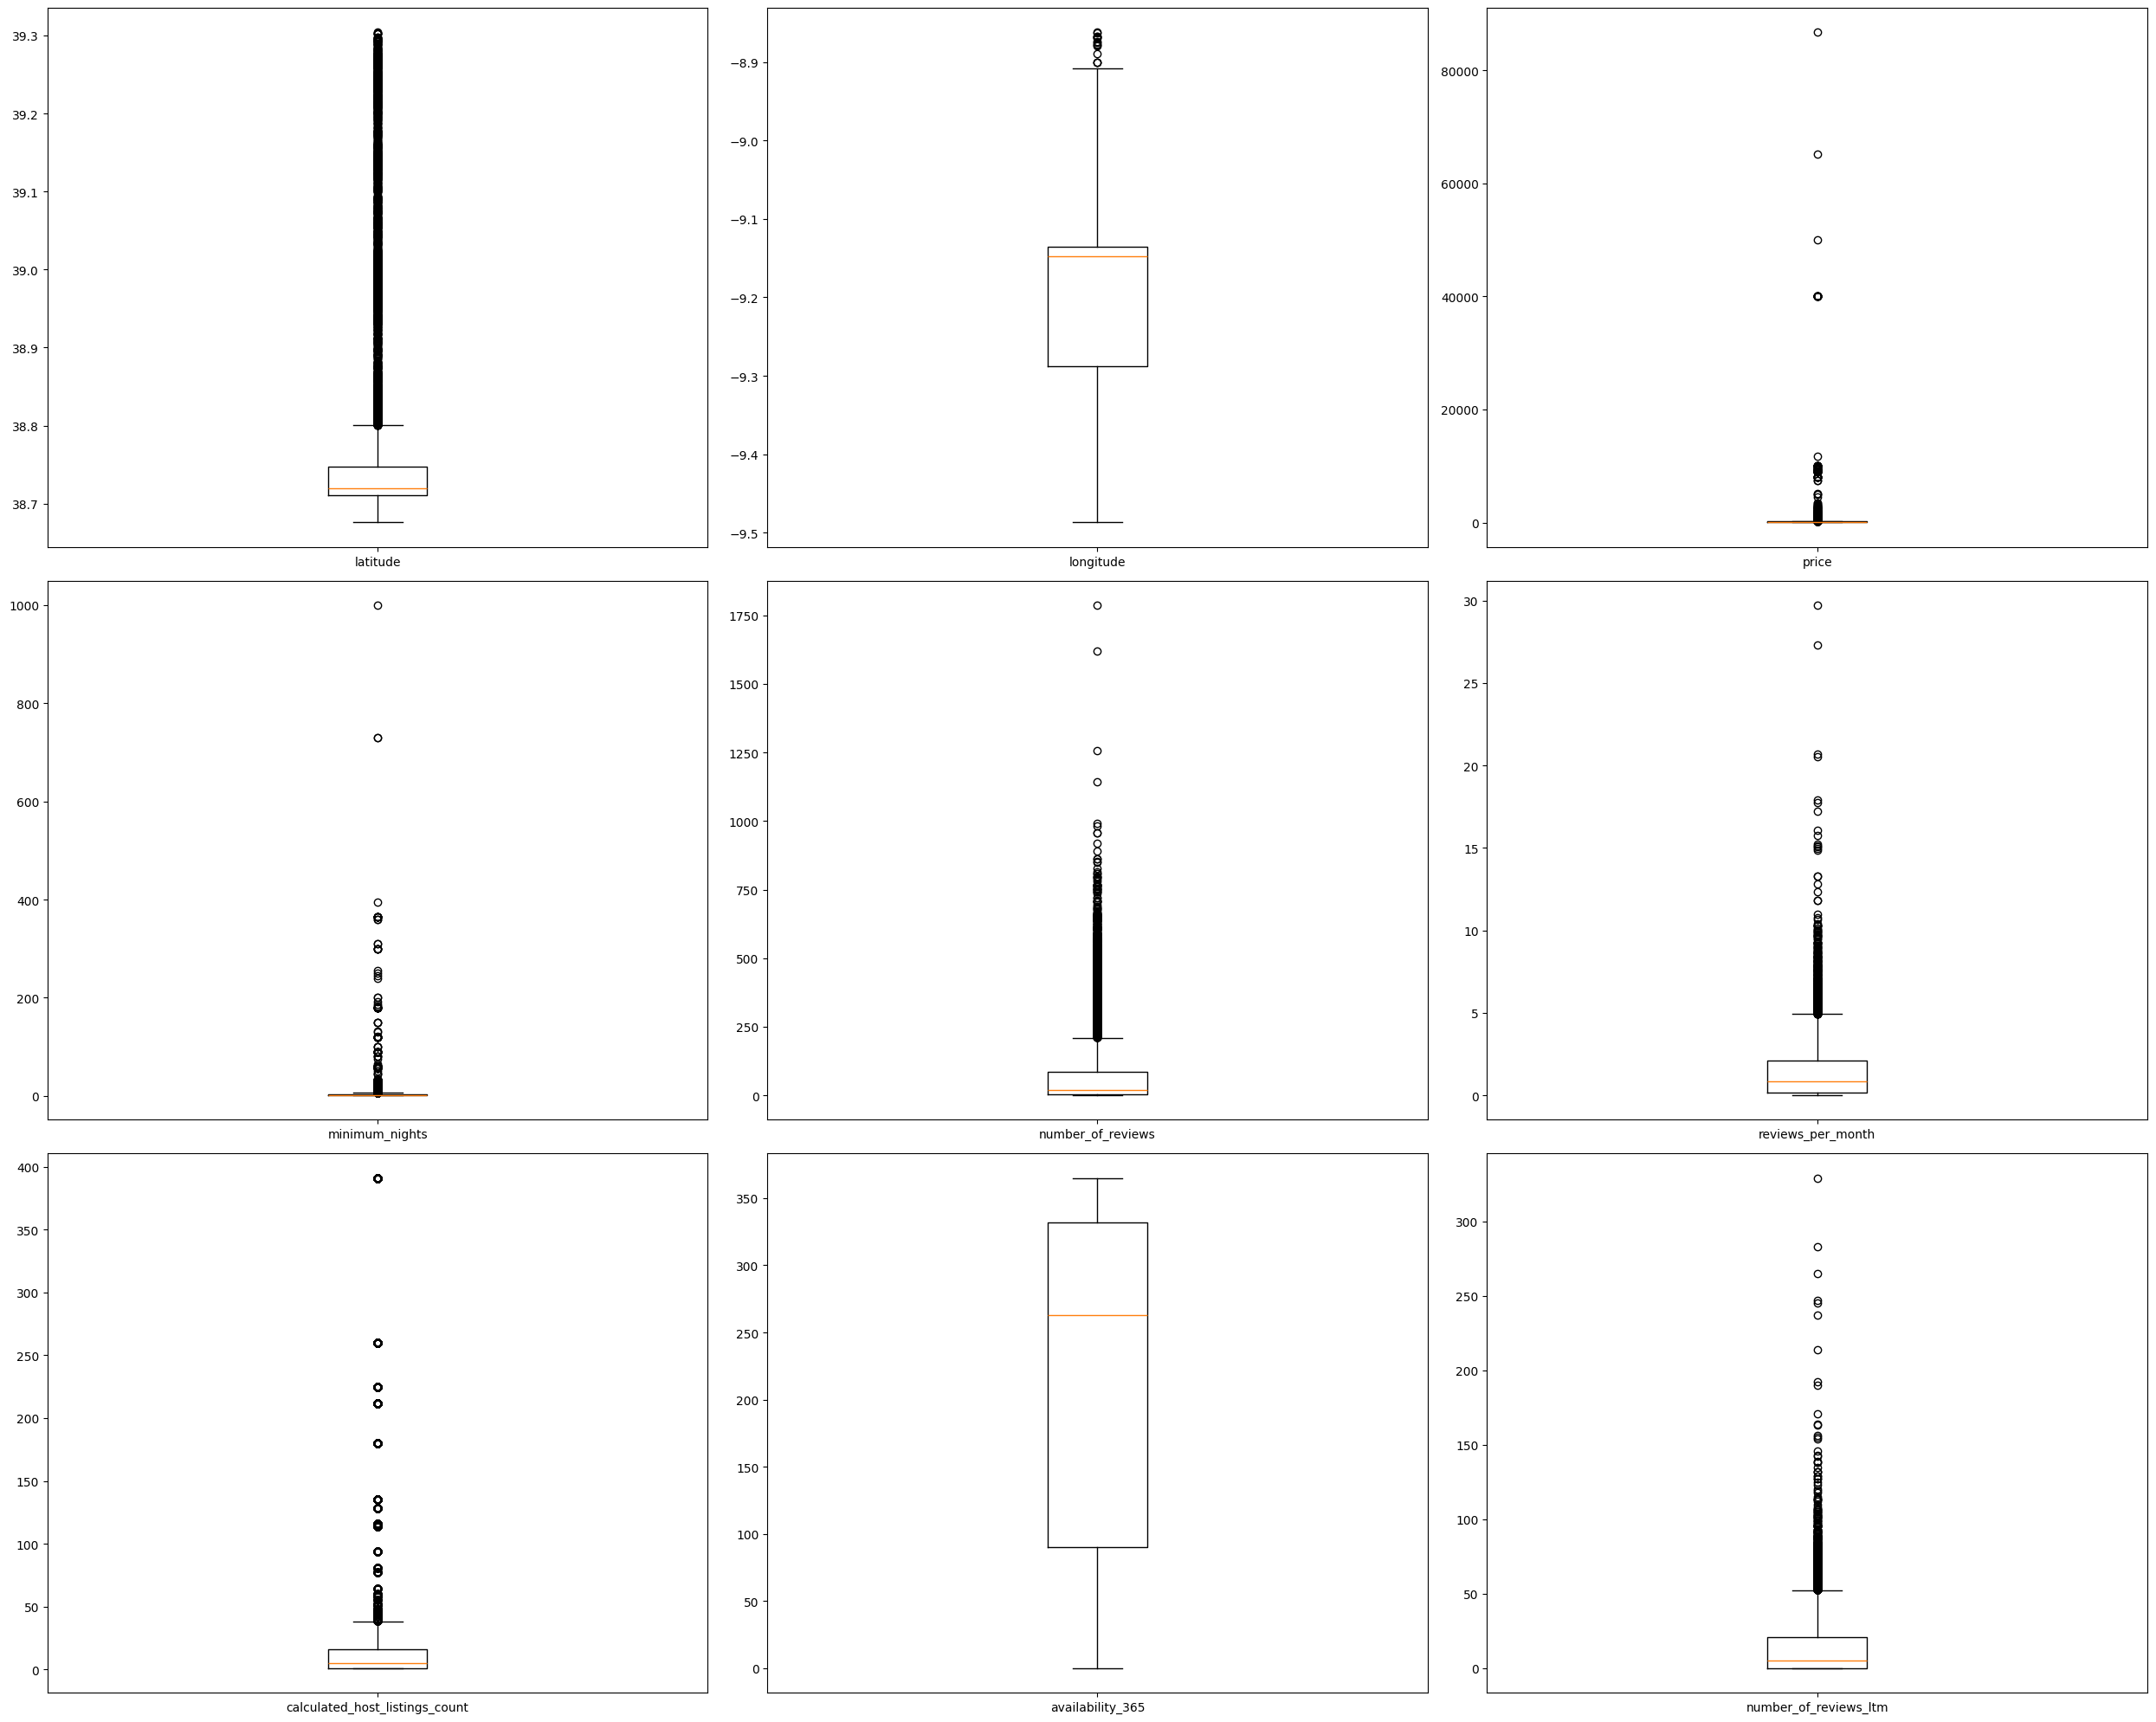

In [32]:
fig, ax = plt.subplots(3,3, figsize=(25,20))

for i, col in enumerate(listings_data_numeric_after_cleaning.columns):
    row, column = divmod(i, 3)
    data = listings_data_numeric_after_cleaning[col].dropna()
    ax[row, column].boxplot(data)
    ax[row, column].set_xticklabels([col])

plt.tight_layout()
plt.show()